# Model Comparison

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('data/cleaned_data.csv')
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn_model  = joblib.load('models/knn.pkl')
knn_scaler = joblib.load('models/knn_scaler.pkl')
svc_model  = joblib.load('models/svc.pkl')
svc_scaler = joblib.load('models/svc_scaler.pkl')
lr_model   = joblib.load('models/logistic.pkl')
lr_scaler  = joblib.load('models/logistic_scaler.pkl')
rf_model   = joblib.load('models/rf.pkl')
gb_model   = joblib.load('models/gb.pkl')
ann_model  = joblib.load('models/ann.pkl')
ann_scaler = joblib.load('models/ann_scaler.pkl')
print('Models loaded. Test size:', X_test.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.6.1. This might lead to breaking code or inval

Models loaded. Test size: (3004, 39)


In [10]:
def evaluate(name, model, X_input):
    y_pred = model.predict(X_input)
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2),
    }
def evaluate_ann(name,model,X_input):
    predictions_vector = model.predict(X_input)
    y_pred = (predictions_vector > 0.5).astype(int).flatten()
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2),
    }

X_test_knn = knn_scaler.transform(X_test)
X_test_svc = svc_scaler.transform(X_test)
X_test_lr  = lr_scaler.transform(X_test)
X_test_ann = ann_scaler.transform(X_test)

results = [
    evaluate('KNN',                knn_model, X_test_knn),
    evaluate('SVC',                svc_model, X_test_svc),
    evaluate('Logistic Regression',lr_model,  X_test_lr),
    evaluate('Random Forest',      rf_model,  X_test),
    evaluate('Gradient Boosting',  gb_model,  X_test),
    evaluate_ann('ANN',                ann_model, X_test_ann),
]

summary = pd.DataFrame(results).set_index('Model')
print(summary.to_string())

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
KNN                     73.04      76.42   72.36     74.33
SVC                     77.23      78.31   79.95     79.12
Logistic Regression     74.23      75.25   77.85     76.53
Random Forest           76.96      79.09   77.91     78.50
Gradient Boosting       78.06      79.65   79.70     79.68
ANN                     76.90      82.99   71.93     77.07


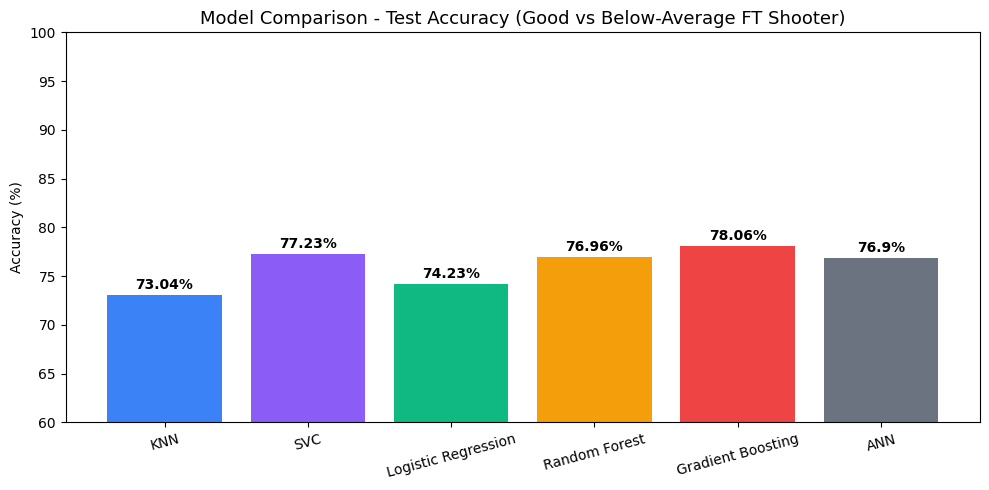

In [11]:
plt.figure(figsize=(10, 5))
colors = ['#3B82F6', '#8B5CF6', '#10B981', '#F59E0B', '#EF4444', '#6B7280']
bars = plt.bar(summary.index, summary['Accuracy'], color=colors)
plt.title('Model Comparison - Test Accuracy (Good vs Below-Average FT Shooter)', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.ylim(60, 100)
plt.xticks(rotation=15)
for bar, val in zip(bars, summary['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()